In [1]:
from dolfinx import default_scalar_type
from dolfinx.fem import (
    Constant,
    Function,
    Expression,
    functionspace,
    assemble_scalar,
    assemble_matrix,
    dirichletbc,
    form,
    locate_dofs_topological,
    locate_dofs_geometrical,
    extract_function_spaces,
)
from dolfinx.fem.petsc import (
    LinearProblem, 
    NonlinearProblem,
    create_matrix, 
    create_vector, 
)
from dolfinx.io import XDMFFile
from dolfinx.mesh import (
    create_unit_square,
    locate_entities,
    meshtags,
    compute_midpoints,
    CellType,
)
from dolfinx.plot import vtk_mesh

from mpi4py import MPI
import ufl
from ufl import (
    FacetNormal,
    Measure,
    SpatialCoordinate,
    TestFunction,
    TrialFunction,
    div,
    dot,
    dx,
    grad,
    inner,
    exp,
    sqrt,
    ln,
    lhs,
    rhs,
    conditional,
    derivative,
)

from petsc4py import PETSc
import numpy as np

from visualization_fct import *
from my_functions import *


In [2]:
# Define time discretization parameters
t = 0.0 # start time
T = 60*60 # end time
delta_t = 30 # time step size
num_steps = int(np.floor(T/delta_t))
print(num_steps)

# Define constants (silt)
alpha = 1.6
N = 1.37
theta_r = 0.034
theta_s = 0.46
Ks = 6.94e-7

120


### Set up mesh, FE space

In [3]:
# Create mesh
# Generate domain from four corner points
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
domain = create_quad_domain(MPI.COMM_WORLD, 20, 20, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)

# Interface
slope = (P1[1]-P0[1])/(P1[0]-P0[0]) # slope of bottom and top boundary

tdim = domain.topology.dim

# Set up FE space
V = functionspace(domain, ("CG", 1)) # linear Lagrange
v = TestFunction(V)
x = SpatialCoordinate(domain)

# Define parametrization

def theta(u):
    t = conditional(u <= 0, theta_r + (theta_s - theta_r)*(1 + (-alpha*u)**N)**(1/N-1), theta_s)
    return t

def Se(u):
    return (theta(u) - theta_r)/(theta_s - theta_r)

def k(u):
    m = 1 - 1/N
    kr = conditional(u <= 0, Se(u)**0.5*(1 - (1 - Se(u)**(1/m))**m)**2, 1)
    return Ks*kr

def C(u):
    m = 1 - 1/N
    Sm = Se(u)**(1/m)
    Cval = conditional(Sm < 1, alpha * m * (theta_s - theta_r) * N * Sm * (1 - Sm)**m, 0)
    #Cval = conditional(u <= 0, (N-1)*alpha*(-alpha*u)**(N-1)*(theta_s - theta_r)/((1 + (-alpha*u)**N)**(2 - 1/N)), 0)
    return Cval


### Set up boundary conditions

In [4]:
# Boundary conditions

# Define the gw table at the right boundary to be below 0.
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)
def gamma_out(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] >= 0)
def gamma_in(x):
    return np.isclose(x[1], slope*x[0]+P3[1])
def bottom(x):
    return np.isclose(x[1], slope*x[0])
def gamma_bed(x):
    return np.logical_or(bottom(x), np.isclose(x[0], 0))

boundaries = [
    (1, gamma_bed),
    (2, on_dirichlet),
    (3, gamma_out),
    (4, gamma_in)
]

# We now loop through all the boundary conditions and create MeshTags identifying the facets for each boundary condition.
facet_indices, facet_markers = [], []
fdim = domain.topology.dim - 1
for marker, locator in boundaries:
    facets = locate_entities(domain, fdim, locator) # find boundary facet
    facet_indices.append(facets)
    facet_markers.append(np.full_like(facets, marker))
facet_indices = np.hstack(facet_indices).astype(np.int32) # make array of arrays into single array
facet_markers = np.hstack(facet_markers).astype(np.int32)
sorted_facets = np.argsort(facet_indices)
facet_tag = meshtags(
    domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]
) # each boundary facet gets identified with its boundary condition

domain.topology.create_connectivity(fdim, domain.topology.dim) # connect facets to cells

# Create custom integration measure
ds = Measure("ds", domain, subdomain_data=facet_tag)

# Create general boundary condition class
class BoundaryCondition:
    def __init__(self, type, marker, values):
        self._type = type
        if type == "Dirichlet":
            facets = facet_tag.find(marker)
            dofs = locate_dofs_topological(V, fdim, facets)
            self._bc = dirichletbc(PETSc.ScalarType(values), dofs, V)
        elif type == "Neumann":
            self._bc = inner(values, v) * ds(marker)
        else:
            raise TypeError("Unknown boundary condition: {0:s}".format(type))

    @property
    def bc(self):
        return self._bc

    @property
    def type(self):
        return self._type

In [5]:
# Define boundary conditions
c_in = 2e-9 # recharge
boundary_conditions = [
    BoundaryCondition("Neumann", 1, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Dirichlet", 2, 0),
    BoundaryCondition("Neumann", 3, Constant(domain, default_scalar_type(0))),
    BoundaryCondition("Neumann", 4, Constant(domain, default_scalar_type(c_in)))
]

bcs = []
for condition in boundary_conditions:
    if condition.type == "Dirichlet":
        bcs.append(condition.bc)

### Start solving

#### Try modified Picard

In [6]:
facets = facet_tag.find(2)
dofs_Dirichlet = locate_dofs_topological(V, fdim, facets)

In [7]:
v = TestFunction(V)
u_n = Function(V)
u_n.x.array[:] = -1e-6*np.ones_like(u_n.x.array) # previous (time step) solution

max_iter = 20 # maximum number of Picard iterations
tol = 1e-6

t = 0.0 # current time

tmp_1 = Function(V)
tmp_2 = Function(V)

while t < T:
    t += delta_t 
    u_m = Function(V)
    u_m.x.array[:] = u_n.x.array # First guess for Picard: previous time step
    du = TrialFunction(V)
    
    # Build variational formulation
    C_part = 1/delta_t * C(u_m) * du * v * dx
    var_part = dot(k(u_m) * grad(du), grad(v)) * dx
    rest = dot(k(u_m) * grad(u_m + x[1]), grad(v)) * dx + (theta(u_m) - theta(u_n)) / delta_t  * v * dx - v*c_in*ds(4)
    F = C_part + var_part + rest

    a_fem = lhs(F)
    L_fem = rhs(F)

    #du = Function(V)
    u_mp1 = Function(V)

    # Prepare Picard iteration
    m = 0 # iteration count
    eps = 1

    while eps > tol and m < max_iter:
        # Calculate boundary conditions for du: du@bd = u_D - u_m@bd
        du_Dirichlet = Function(V)
        du_Dirichlet.x.array[:] = 0 - u_m.x.array
        bc_du = dirichletbc(du_Dirichlet, dofs_Dirichlet)

        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_du],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_"
            )
        du = problem.solve()

        u_mp1.x.array[:] = u_m.x.array + du.x.array # make sure capillary head stays nonpositive
        """ if m == 0:
            tmp_1.x.array[:] = u_mp1.x.array
        else:
            tmp_2.x.array[:] = u_mp1.x.array """
        eps = np.linalg.norm(du.x.array, ord=np.inf)
        print(f"Time {t} s, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")
        u_m.x.array[:] = u_mp1.x.array
        m += 1

    """ # Adaptive time stepping:
    if m > 8 and delta_t > 1e-1:
        delta_t *= 0.5
    if m < 3:
        delta_t *= 1.2 """

    u_n.x.array[:] = u_mp1.x.array

Time 30.0 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.095e-01
Time 30.0 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 1.126e+00
Time 30.0 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 4.863e-01
Time 30.0 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.168e-01
Time 30.0 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 1.377e-01
Time 30.0 s, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.160e-01
Time 30.0 s, iteration 6, Error ||u_n^m-u_n^(m+1)|| 1.849e-01
Time 30.0 s, iteration 7, Error ||u_n^m-u_n^(m+1)|| 2.239e-01
Time 30.0 s, iteration 8, Error ||u_n^m-u_n^(m+1)|| 2.987e-01
Time 30.0 s, iteration 9, Error ||u_n^m-u_n^(m+1)|| 1.435e-01
Time 30.0 s, iteration 10, Error ||u_n^m-u_n^(m+1)|| 5.326e-02
Time 30.0 s, iteration 11, Error ||u_n^m-u_n^(m+1)|| 2.728e-02
Time 30.0 s, iteration 12, Error ||u_n^m-u_n^(m+1)|| 6.841e-03
Time 30.0 s, iteration 13, Error ||u_n^m-u_n^(m+1)|| 1.845e-03
Time 30.0 s, iteration 14, Error ||u_n^m-u_n^(m+1)|| 1.474e-04
Time 30.0 s, iteration 15, Error ||u_n^m-u_n^(m+1)|| 5.670e-06
Ti

Time 60.0 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 7.384e-03
Time 60.0 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 1.990e-03
Time 60.0 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 7.928e-04
Time 60.0 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 2.467e-05
Time 60.0 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 5.363e-07
Time 90.0 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 4.881e-03
Time 90.0 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 9.577e-04
Time 90.0 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 1.634e-04
Time 90.0 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.764e-05
Time 90.0 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 1.770e-06
Time 90.0 s, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.590e-07
Time 120.0 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 4.008e-03
Time 120.0 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 6.299e-04
Time 120.0 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 9.008e-05
Time 120.0 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 9.106e-06
Time 120.0 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 2.555e-06
Tim

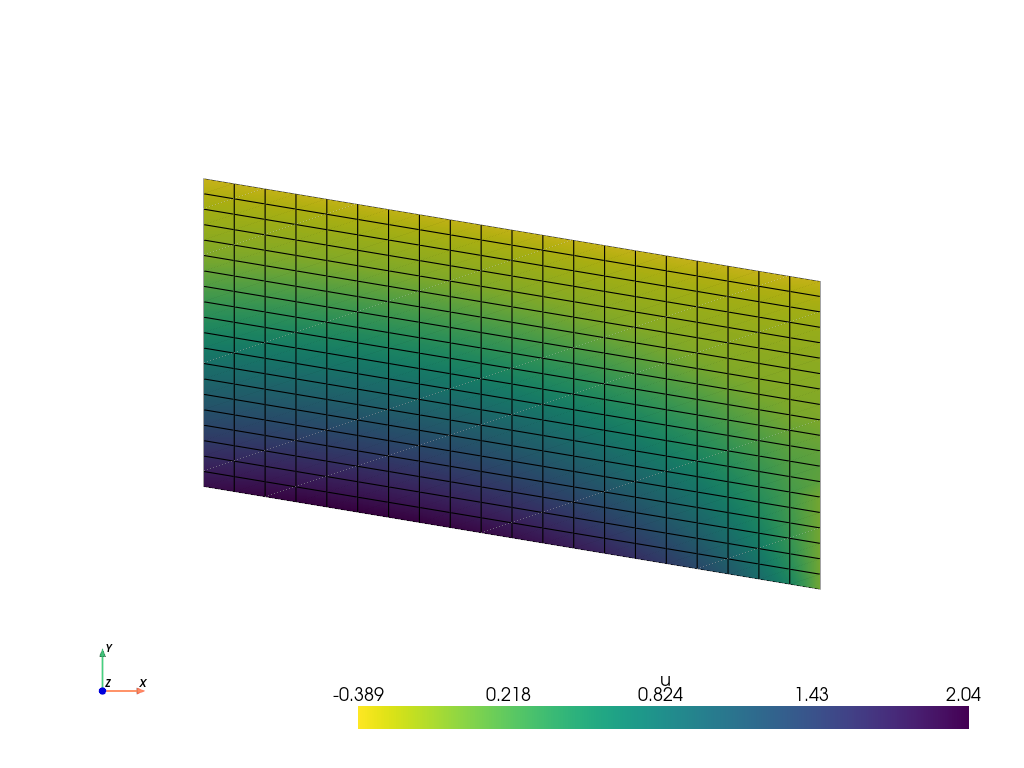

In [ ]:
plotScalarFunction(V, u_n, cmap="viridis_r")

In [ ]:
fun = Function(V)
expr = fem.Expression(C(tmp_1), V.element.interpolation_points)
fun.interpolate(expr)
fun.x.array

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.64942024e-03,
       1.55614214e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 1.78264884e-03, 1.76476554e-03, 1.48127381e-03,
      

### Newton doesn't converge so far

In [ ]:
v = TestFunction(V)
uh = Function(V)
u_N = Function(V)
u_N.x.array[:] = -1e-6*np.ones_like(u_N.x.array) # initial value
x = SpatialCoordinate(domain)

F = C(uh) / delta_t * (uh - u_N) * v * dx
F += inner(k(uh) * grad(x[1] + uh), grad(v)) * dx - v*c_in*ds(4)

J = derivative(F, uh)

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-10,
    "snes_rtol": 1e-10,
    "snes_monitor_cancel": None,
    "ksp_error_if_not_converged": True,
    "ksp_type": "preonly",
    "ksp_rtol": 1e-10,
    "ksp_monitor_cancel": None,
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

for n in range(num_steps):
    problem = NonlinearProblem(
        F,
        uh,
        bcs=bcs,
        J=J,
        petsc_options=petsc_options,
        petsc_options_prefix="SNES_",
    )

    uh = problem.solve()
    converged = problem.solver.getConvergedReason()
    num_iter = problem.solver.getIterationNumber()
    assert converged > 0, f"Solver did not converge, got {converged}."
    print(
        f"Solver converged at timestep {n} after {num_iter} iterations with converged reason {converged}."
    )

    u_N.x.array[:] = uh.x.array

AssertionError: Solver did not converge, got -4.

In [ ]:
n

0

## Compare clipped to not-clipped version

In [10]:
not_clipped = Function(V)
not_clipped.x.array[:] = np.load("richards_notclipped_1day.npy")
clipped = Function(V)
clipped.x.array[:] = np.load("richards_clipped_1day.npy")

# Create parameter space
n = 20
x_int = np.linspace(0, 1, n)
y_int = np.linspace(0, 1, n)
x_int, y_int = np.meshgrid(x_int, y_int)

# Bilinear interpolation
x_grid = (1 - x_int) * (1 - y_int) * P0[0] + x_int * (1 - y_int) * P1[0] + x_int * y_int * P2[0] + (1 - x_int) * y_int * P3[0]
y = (1 - x_int) * (1 - y_int) * P0[1] + x_int * (1 - y_int) * P1[1] + x_int * y_int * P2[1] + (1 - x_int) * y_int * P3[1]


# Combine into a grid of points
grid = np.column_stack((x_grid.ravel(), y.ravel()))
x_grid = x_grid.reshape((n,n))
z_grid = y.reshape((n,n))

h_clipped = eval_fct_on_grid(grid, [clipped], domain).reshape((n,n))
h_not = eval_fct_on_grid(grid, [not_clipped], domain).reshape((n,n))


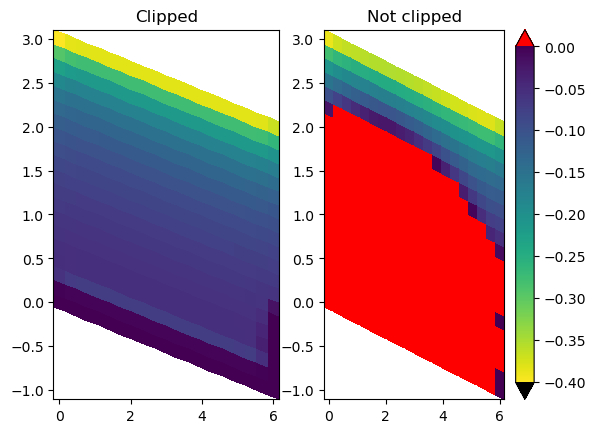

In [17]:
vmin = np.min([h_clipped, h_not])
vmax = np.max([h_clipped, np.zeros_like(h_not)])

cmap = plt.cm.viridis_r.copy()

# Special colors
cmap.set_under("black")   # values < vmin
cmap.set_over("red")      # values > vmax


fig, ax = plt.subplots(1,2)
pmesh0 = ax[0].pcolormesh(x_grid, z_grid, h_clipped, vmin=vmin, vmax=vmax, cmap=cmap)
ax[0].set_title("Clipped")
pmesh1 = ax[1].pcolormesh(x_grid, z_grid, h_not, vmin=vmin, vmax=vmax, cmap=cmap)
ax[1].set_title("Not clipped")
fig.colorbar(pmesh1, ax = ax[1], extend="both")

## Test

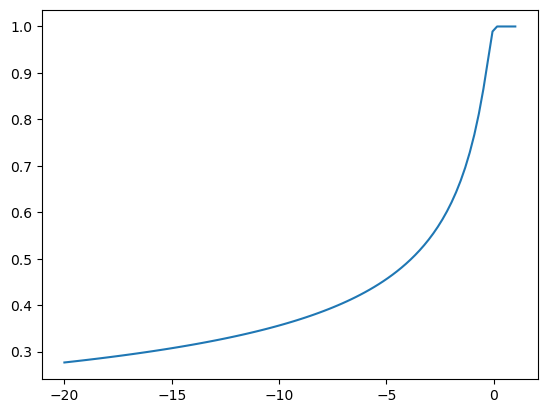

In [ ]:
alpha = 1.6
N = 1.37
theta_r = 0.034
theta_s = 0.46
Ks = 6.94e-7
def Se(psi):
    return (theta(psi) - theta_r)/(theta_s - theta_r)

def theta(psi):
    t = np.zeros_like(psi)
    for i, h in enumerate(psi):
        if h < 0:
            t[i] = theta_r + (theta_s - theta_r)*(1 + (alpha*(-h))**N)**(1/N-1)
        else:
            t[i] = theta_s
    return t

def kr(psi):
    m = 1 - 1/N
    return Se(psi)**0.5*(1 - (1 - Se(psi)**(1/m))**m)**2

psi = np.linspace(-20, 1, 100)
plt.plot(psi, Se(psi))